# Customer Churn Intelligence: Predicting Customer Loss and Improving Retention Strategy

## 1. Business Understanding

Customer churn is a major business problem for subscription-based companies because losing customers directly affects revenue and long-term growth. This project analyses telecom customer data to identify churn patterns, understand key churn drivers, build a predictive model, and recommend data-driven retention strategies.

## Project Objectives

1. Analyse customer churn behaviour.
2. Identify customer segments with high churn risk.
3. Build a machine learning model to predict churn.
4. Develop business recommendations to improve customer retention.
5. Create a Power BI dashboard for decision-makers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/telco_customer_churn_raw.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## 3. Data Cleaning

In this step, the dataset is checked for duplicates, missing values, and incorrect data types. The `TotalCharges` column is converted from text to numeric format because it is required for analysis and modelling.

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4. Feature Engineering

New columns are created to support business analysis and predictive modelling. `Churn_Flag` converts churn into numeric format, while tenure and monthly charge groups help identify customer segments with different churn risk levels.

In [12]:
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

df[['Churn', 'Churn_Flag']].head()

,Churn,Churn_Flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [13]:
def create_tenure_group(tenure):
    if tenure <= 12:
        return '0-12 Months'
    elif tenure <= 24:
        return '13-24 Months'
    elif tenure <= 48:
        return '25-48 Months'
    else:
        return '49+ Months'

df['Tenure_Group'] = df['tenure'].apply(create_tenure_group)

df[['tenure', 'Tenure_Group']].head()

,tenure,Tenure_Group
0,1,0-12 Months
1,34,25-48 Months
2,2,0-12 Months
3,45,25-48 Months
4,2,0-12 Months


In [14]:
def monthly_charge_group(charge):
    if charge < 35:
        return 'Low Charge'
    elif charge < 70:
        return 'Medium Charge'
    else:
        return 'High Charge'

df['Monthly_Charge_Group'] = df['MonthlyCharges'].apply(monthly_charge_group)

df[['MonthlyCharges', 'Monthly_Charge_Group']].head()

,MonthlyCharges,Monthly_Charge_Group
0,29.85,Low Charge
1,56.95,Medium Charge
2,53.85,Medium Charge
3,42.30,Medium Charge
4,70.70,High Charge


In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,Tenure_Group,Monthly_Charge_Group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 Months,Low Charge
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 Months,Medium Charge
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 Months,Medium Charge
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 Months,Medium Charge
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 Months,High Charge


## 5. Business KPI Analysis

This section calculates key business metrics such as total customers, churned customers, churn rate, monthly revenue, and revenue at risk. These KPIs help measure the business impact of customer churn.

In [16]:
total_customers = df['customerID'].nunique()
total_customers

7043

In [17]:
churned_customers = df[df['Churn'] == 'Yes']['customerID'].nunique()
churned_customers

1869

In [18]:
churn_rate = df['Churn_Flag'].mean() * 100
round(churn_rate, 2)

np.float64(26.54)

In [19]:
monthly_revenue = df['MonthlyCharges'].sum()
round(monthly_revenue, 2)

np.float64(456116.6)

In [20]:
revenue_at_risk = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()
round(revenue_at_risk, 2)

np.float64(139130.85)

In [21]:
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'Churned Customers',
        'Churn Rate (%)',
        'Monthly Revenue',
        'Revenue at Risk'
    ],
    'Value': [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(monthly_revenue, 2),
        round(revenue_at_risk, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Churn Rate (%),26.54
3,Monthly Revenue,456116.60
4,Revenue at Risk,139130.85


## 6. Exploratory Data Analysis

Exploratory data analysis is used to identify churn patterns across customer contract type, payment method, tenure group, and monthly charge group. These patterns help understand which customer segments have higher churn risk.

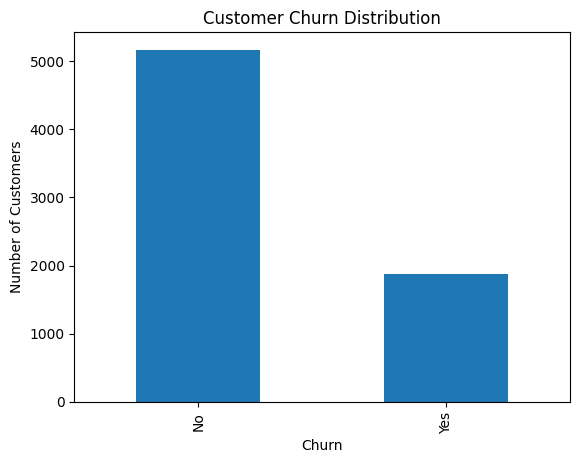

In [22]:
df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [23]:
contract_churn = df.groupby('Contract')['Churn_Flag'].mean().sort_values(ascending=False) * 100
contract_churn

,Churn_Flag
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


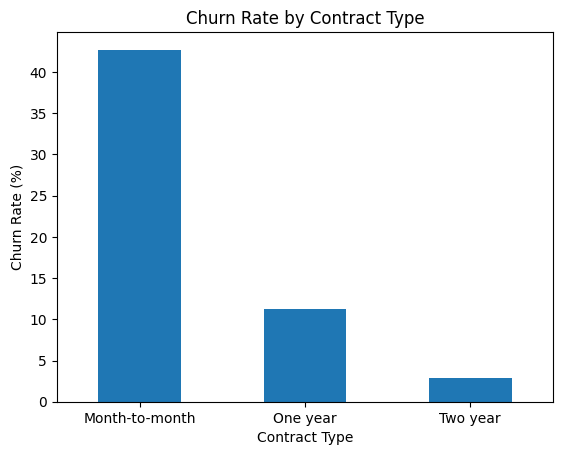

In [24]:
contract_churn.plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [25]:
tenure_churn = df.groupby('Tenure_Group')['Churn_Flag'].mean() * 100
tenure_churn

,Churn_Flag
Tenure_Group,
0-12 Months,47.438243
13-24 Months,28.710938
25-48 Months,20.388959
49+ Months,9.513176


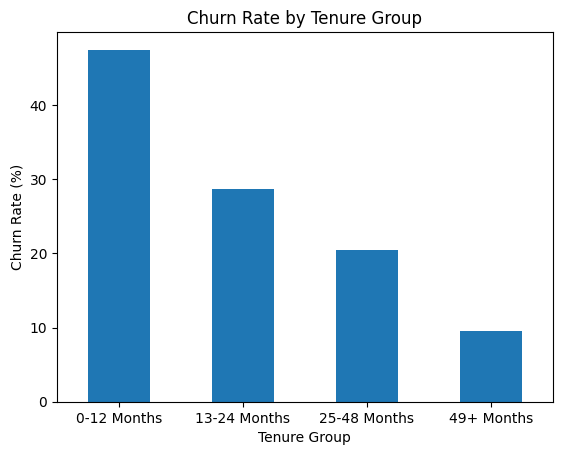

In [26]:
tenure_churn.plot(kind='bar')

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

### Initial EDA Insights

The churn distribution shows that most customers stayed with the company, while 1,869 customers churned. The overall churn rate is 26.54%, which means approximately one in four customers left the company.

The contract analysis shows that month-to-month customers have the highest churn rate compared to one-year and two-year contract customers. This suggests that customers with flexible contracts are more likely to leave.

The tenure analysis shows that customers in the first 12 months have the highest churn rate. Churn decreases as tenure increases, meaning long-term customers are more loyal and less likely to leave.

In [27]:
payment_churn = df.groupby('PaymentMethod')['Churn_Flag'].mean().sort_values(ascending=False) * 100
payment_churn

,Churn_Flag
PaymentMethod,
Electronic check,45.285412
Mailed check,19.106700
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101


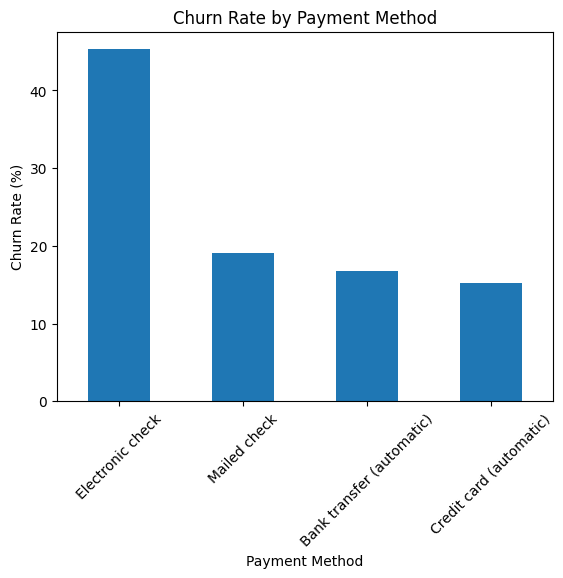

In [28]:
payment_churn.plot(kind='bar')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [29]:
charge_churn = df.groupby('Monthly_Charge_Group')['Churn_Flag'].mean().sort_values(ascending=False) * 100
charge_churn

,Churn_Flag
Monthly_Charge_Group,
High Charge,35.477583
Medium Charge,23.649041
Low Charge,10.860774


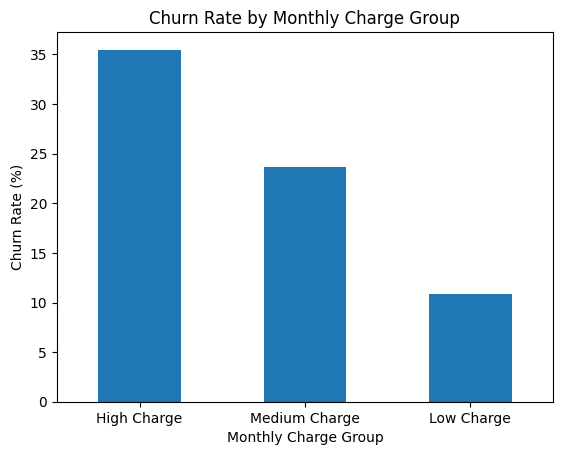

In [30]:
charge_churn.plot(kind='bar')

plt.title('Churn Rate by Monthly Charge Group')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

### Additional EDA Insights

The payment method analysis shows that customers using electronic cheque have the highest churn rate compared to other payment methods. This may indicate that payment experience or customer profile differences are linked with churn risk.

The monthly charge analysis shows that high-charge customers have the highest churn rate, while low-charge customers have the lowest churn rate. This suggests that price sensitivity may be an important factor in customer churn.

## 7. Export Cleaned Dataset

The cleaned dataset is exported as a CSV file so it can be used for SQL analysis and Power BI dashboard development.

In [31]:
df.to_csv('/content/cleaned_customer_churn.csv', index=False)

In [32]:
from google.colab import files
files.download('/content/cleaned_customer_churn.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Predictive Modelling

In this section, machine learning models are developed to predict whether a customer is likely to churn. Two models are used: Logistic Regression and Random Forest. The models are compared using accuracy, precision, recall, and F1-score.

For churn prediction, recall is especially important because the business wants to identify as many actual churn customers as possible before they leave.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [35]:
X = df.drop(columns=['customerID', 'Churn', 'Churn_Flag'])
y = df['Churn_Flag']

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Tenure_Group,Monthly_Charge_Group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0-12 Months,Low Charge
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,25-48 Months,Medium Charge
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0-12 Months,Medium Charge
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,25-48 Months,Medium Charge
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0-12 Months,High Charge


In [36]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Tenure_Group',
       'Monthly_Charge_Group'],
      dtype='object')


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5634
Testing rows: 1409


In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [40]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

In [41]:
print("Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_lr), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.7991
Precision: 0.6522
Recall: 0.5214
F1 Score: 0.5795

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [42]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [43]:
print("Random Forest Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.7842
Precision: 0.6215
Recall: 0.4786
F1 Score: 0.5408

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [44]:
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_rf), 4)
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_rf), 4)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_rf), 4)
    ],
    'F1 Score': [
        round(f1_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_rf), 4)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7991,0.6522,0.5214,0.5795
1,Random Forest,0.7842,0.6215,0.4786,0.5408


### Model Evaluation Insight

Two machine learning models were tested: Logistic Regression and Random Forest. Logistic Regression performed better overall, with higher accuracy, recall, and F1-score compared to Random Forest.

For this churn prediction problem, recall is an important metric because the business wants to identify customers who are likely to churn before they leave. Based on the model comparison, Logistic Regression was selected as the final model for churn risk prediction.

In [45]:
df_powerbi = df.copy()

df_powerbi['Predicted_Churn'] = logistic_model.predict(X)
df_powerbi['Churn_Probability'] = logistic_model.predict_proba(X)[:, 1]

df_powerbi['Risk_Level'] = pd.cut(
    df_powerbi['Churn_Probability'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df_powerbi[['customerID', 'Churn', 'Predicted_Churn', 'Churn_Probability', 'Risk_Level']].head()

,customerID,Churn,Predicted_Churn,Churn_Probability,Risk_Level
0,7590-VHVEG,No,1,0.600172,High Risk
1,5575-GNVDE,No,0,0.039247,Low Risk
2,3668-QPYBK,Yes,0,0.318138,Medium Risk
3,7795-CFOCW,No,0,0.027839,Low Risk
4,9237-HQITU,Yes,1,0.711597,High Risk


## 9. Export Final Dataset for Power BI

The final dataset includes cleaned fields, engineered features, churn prediction results, churn probability, and customer risk level. This dataset will be used to build the Power BI dashboard.

In [46]:
df_powerbi.to_csv('/content/customer_churn_powerbi.csv', index=False)

In [47]:
from google.colab import files
files.download('/content/customer_churn_powerbi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>